<a href="https://colab.research.google.com/github/Manasa19092006/conference_paper/blob/main/Ai_job.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving AI_Job_Market_Trends_2026.csv to AI_Job_Market_Trends_2026.csv


In [ ]:
df = pd.read_csv("AI_Job_Market_Trends_2026.csv")

print(df.head())

   job_id                  job_title company_size company_industry    country  \
0       1                AI Engineer      Startup           Retail     Canada   
1       2  Machine Learning Engineer          MNC       Technology  Australia   
2       3  Machine Learning Engineer          MNC       Technology    Germany   
3       4           Business Analyst      Startup       Healthcare    Germany   
4       5             Data Scientist          MNC       Healthcare    Germany   

  remote_type experience_level  years_experience education_level  \
0      Remote           Senior                 2          Master   
1      Hybrid              Mid                 0        Bachelor   
2      Onsite              Mid                14          Master   
3      Remote              Mid                 9          Master   
4      Hybrid              Mid                 5          Master   

   skills_python  skills_sql  skills_ml  skills_deep_learning  skills_cloud  \
0              0         

In [ ]:
print(df.isnull().sum())

job_id                  0
job_title               0
company_size            0
company_industry        0
country                 0
remote_type             0
experience_level        0
years_experience        0
education_level         0
skills_python           0
skills_sql              0
skills_ml               0
skills_deep_learning    0
skills_cloud            0
salary                  0
job_posting_month       0
job_posting_year        0
hiring_urgency          0
job_openings            0
dtype: int64


In [ ]:
label_encoder = LabelEncoder()

categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

print(df.head())

   job_id  job_title  company_size  company_industry  country  remote_type  \
0       1          0             3                 4        1            2   
1       2          5             1                 5        0            0   
2       3          5             1                 5        2            1   
3       4          1             3                 3        2            2   
4       5          4             1                 3        2            0   

   experience_level  years_experience  education_level  skills_python  \
0                 2                 2                1              0   
1                 1                 0                0              1   
2                 1                14                1              1   
3                 1                 9                1              0   
4                 1                 5                1              1   

   skills_sql  skills_ml  skills_deep_learning  skills_cloud  salary  \
0           0       

In [ ]:
X = df.drop(['salary', 'job_id'], axis=1)

y = df['salary']

In [ ]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Size :", len(X_train))
print("Testing Size  :", len(X_test))

Training Size : 8276
Testing Size  : 2069


In [ ]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [ ]:
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)


DecisionTreeRegressor(random_state=42)

In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Models Trained Successfully")

Models Trained Successfully


In [ ]:
lr_pred = lr_model.predict(X_test)

dt_pred = dt_model.predict(X_test)

rf_pred = rf_model.predict(X_test)

In [ ]:
def evaluate_model(name, y_test, pred):

    mae = mean_absolute_error(y_test, pred)

    mse = mean_squared_error(y_test, pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test, pred)

    accuracy = r2 * 100

    print("\n", "="*50)

    print(name)

    print("="*50)

    print("MAE       :", round(mae, 2))

    print("MSE       :", round(mse, 2))

    print("RMSE      :", round(rmse, 2))

    print("R2 Score  :", round(r2, 4))

    print("Accuracy  :", round(accuracy, 2), "%")


In [ ]:
evaluate_model(
    "Linear Regression",
    y_test,
    lr_pred
)

evaluate_model(
    "Decision Tree Regression",
    y_test,
    dt_pred
)

evaluate_model(
    "Random Forest Regression",
    y_test,
    rf_pred
)


Linear Regression
MAE       : 18367.89
MSE       : 437774331.03
RMSE      : 20923.06
R2 Score  : 0.5603
Accuracy  : 56.03 %

Decision Tree Regression
MAE       : 3433.21
MSE       : 18347044.14
RMSE      : 4283.34
R2 Score  : 0.9816
Accuracy  : 98.16 %

Random Forest Regression
MAE       : 2714.3
MSE       : 11074319.37
RMSE      : 3327.81
R2 Score  : 0.9889
Accuracy  : 98.89 %


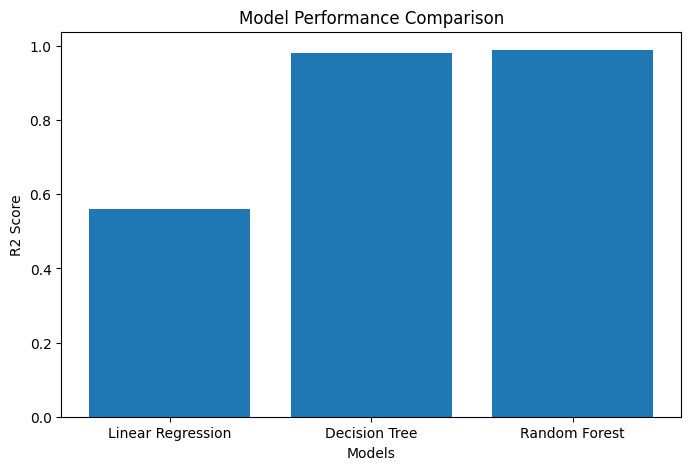

In [ ]:
models = [
    'Linear Regression',
    'Decision Tree',
    'Random Forest'
]

r2_scores = [
    r2_score(y_test, lr_pred),
    r2_score(y_test, dt_pred),
    r2_score(y_test, rf_pred)
]

plt.figure(figsize=(8,5))

plt.bar(models, r2_scores)

plt.title("Model Performance Comparison")

plt.xlabel("Models")

plt.ylabel("R2 Score")

plt.show()

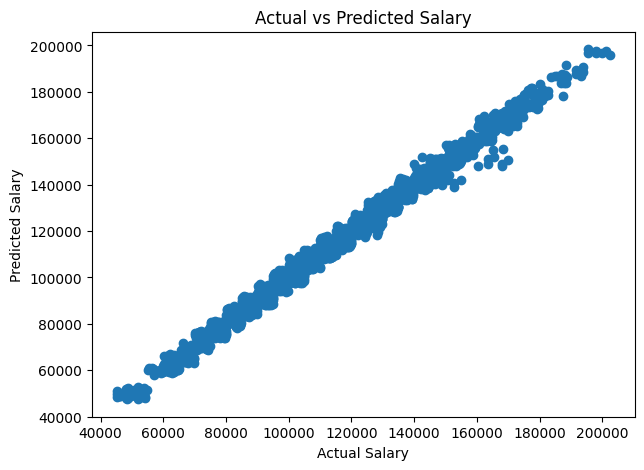

In [ ]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, rf_pred)

plt.xlabel("Actual Salary")

plt.ylabel("Predicted Salary")

plt.title("Actual vs Predicted Salary")

plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
threshold = y_test.mean()

y_test_class = (y_test > threshold).astype(int)

rf_pred_class = (rf_pred > threshold).astype(int)

In [ ]:
cm = confusion_matrix(
    y_test_class,
    rf_pred_class
)

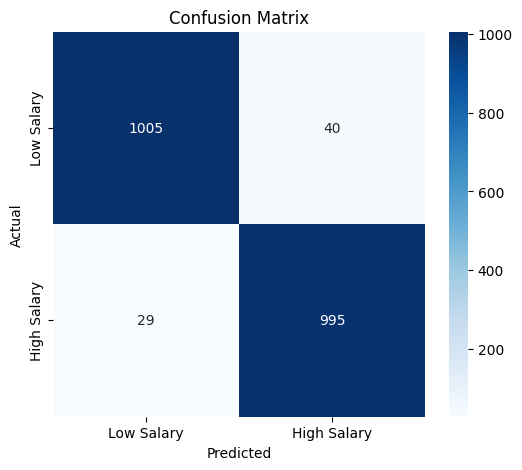

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Low Salary', 'High Salary'],
    yticklabels=['Low Salary', 'High Salary']
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import r2_score

import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
threshold = y_test.mean()

In [ ]:
y_test_class = (y_test > threshold).astype(int)

In [ ]:
rf_pred_class = (rf_pred > threshold).astype(int)

In [ ]:
cm = confusion_matrix(
    y_test_class,
    rf_pred_class
)

In [ ]:
accuracy = accuracy_score(
    y_test_class,
    rf_pred_class
)

In [ ]:
r2 = r2_score(
    y_test,
    rf_pred
)

In [ ]:
print("Accuracy :", round(accuracy * 100, 2), "%")

print("R2 Score :", round(r2, 4))

Accuracy : 96.67 %
R2 Score : 0.9889


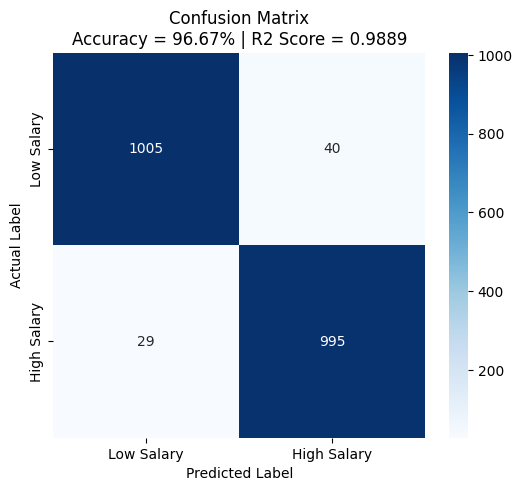

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Low Salary', 'High Salary'],
    yticklabels=['Low Salary', 'High Salary']
)

plt.xlabel("Predicted Label")

plt.ylabel("Actual Label")

plt.title(
    f"Confusion Matrix\nAccuracy = {accuracy*100:.2f}% | R2 Score = {r2:.4f}"
)

plt.show()